In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
import sys

In [2]:
import sklearn
print(sklearn.__version__)

1.3.2


In [3]:
import warnings
# Suppress all FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [4]:
genetic = pd.read_csv("Expression_log2_21_primaryNivo_braun_2020.csv",index_col=0)
genetic

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
gene_name,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,30.187983,22.999432,33.643965,37.130851,22.705126,22.869853,21.076515,21.271282,21.807184,33.279532,...,33.26816,30.04056,30.36292,30.98129,32.38442,28.01561,31.24379,33.81903,33.22469,31.23383
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,30.483638,25.581769,28.866645,37.945043,27.797609,24.142100,21.076515,21.271282,21.807184,33.019435,...,31.53633,29.94062,30.80829,30.74475,32.09470,26.32526,32.70057,33.67262,33.10198,32.44643
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,30.092851,26.933385,26.684228,36.851946,22.705126,30.406352,21.076515,21.271282,21.807184,31.033210,...,30.74474,31.95812,30.73898,30.15898,31.69473,26.33098,32.68330,33.96047,32.97135,32.20607
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,30.975010,26.683128,32.521494,38.453517,26.337846,28.229357,21.076515,21.271282,26.484608,33.009203,...,31.63196,30.71732,31.09654,30.25757,31.90774,27.53819,32.64194,34.54254,33.24885,32.78278
G138701_RCCBMS-00163-T_v1_RNA_OnPrem,26.915750,22.999432,23.219176,38.931987,22.705126,22.869853,21.076515,21.271282,21.807184,31.447751,...,31.75620,30.75149,30.55896,30.17101,31.01545,21.45312,32.86620,34.24375,34.86720,32.73361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P66507-04D-Run1_S3_L001,29.718678,21.286965,33.059162,35.566022,21.357557,27.686244,20.980667,25.034267,21.018133,33.704298,...,28.60179,30.27215,31.08287,31.21266,33.18573,29.26041,31.70839,32.97611,34.23396,32.87393
P66507-07G-Run1_S17_L002,31.147910,21.286965,31.617351,37.423994,21.357557,27.720569,20.980667,20.992693,28.011280,35.638479,...,26.14211,31.31652,31.24066,31.34713,33.06662,27.08693,30.62278,35.10264,33.68084,30.73622
P66425-03B-Run1_S10_L001,30.099518,25.040893,33.891608,38.289830,21.357557,26.870362,20.980667,20.992693,21.018133,33.654328,...,32.54706,29.97152,31.22229,30.38211,31.30604,27.29504,32.44263,34.20699,32.80918,32.29759


In [5]:
cl = pd.read_csv("braun_data_clinical_data.csv",index_col=0)
dfcl = cl.loc[genetic.index,:][cl["Benefit"].isin(["CB","NCB"])]

/tmp/ipykernel_3390003/3204985976.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfcl = cl.loc[genetic.index,:][cl["Benefit"].isin(["CB","NCB"])]


In [6]:
dfmerge = pd.merge(genetic.reset_index(),cl.reset_index(),how='left', left_on="gene_name", right_on="RNA_ID")
dfmerge.shape

(133, 20561)

In [7]:
modelinput_expr = genetic.loc[dfcl.index.tolist()]
print(modelinput_expr.shape)
modeltarget_expr = dfcl["Benefit"].replace("NCB",0).replace("CB",1).tolist()

(90, 20545)


In [8]:
# SFS

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ modelinput_expr.copy()],\
        ["expression"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        # Evaluate the pipeline with LOOCV
        scores = []
        y_resonse = []
        y_pred_list = []
        
        for train_index, test_index in loo.split(datetype):
            print(test_index)
            # Split data into train and test for this fold
            X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
            y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif,k=100)), 
                ('SequentialFeatureSelector', SequentialFeatureSelector(base_model, n_features_to_select='auto', 
                                    direction='forward', cv=5, n_jobs=-1)),
                ('logistic_regression', model)       # Logistic Regression model
        ])
        

            # Fit the pipeline on the training data
            pipeline.fit(X_train, y_train)
            
            # Predict on the test data
            y_pred = pipeline.predict(X_test)
            
            y_resonse.append(y_test)
            y_pred_list.append(y_pred)
            # Store the accuracy for this fold
            scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
        results.append(sum(scores)/len(scores))
        names.append(name)
        print(name, sum(scores)/len(scores))
        

NameError: name 'LogisticRegression' is not defined

In [ ]:
# Hyperparameter

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ modelinput_expr.copy()],\
        ["expression"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        # Evaluate the pipeline with LOOCV
        scores = []
        y_resonse = []
        y_pred_list = []
        
        for train_index, test_index in loo.split(datetype):
            print(test_index)
            # Split data into train and test for this fold
            X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
            y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Define parameter grid for GridSearchCV
            param_grid = {
                'feature_selection__k': [num*10 for num in range(1,10)],  # Number of features to select
                #'logistic_regression__C': [num/10 for num in range(1,11)]  # Regularization parameter
            }
    
            # Apply GridSearchCV on training data
            grid_search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring='accuracy',
                cv=5,  # Perform internal k-fold CV on the training set
                n_jobs=-1
            )
            grid_search.fit(X_train, y_train)

            best_pipeline = grid_search.best_estimator_
            y_pred = best_pipeline.predict(X_test)
            
            y_resonse.append(y_test)
            y_pred_list.append(y_pred)
            # Store the accuracy for this fold
            scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
        results.append(sum(scores)/len(scores))
        names.append(name)
        print(name, sum(scores)/len(scores))
        

# network features input are avaiable:

In [9]:
edges_read = pd.read_csv("primaryNivo_common_edges_adjusted+var10000.txt",index_col=0)

edges_selected = edges_read.copy()
edges_input = edges_selected.loc[modelinput_expr.index,:]

# combination of gene expression and gene coexpression

In [10]:
modelinput_expr.join(edges_input,lsuffix='expr', rsuffix='edges')

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,...,HSD3B7_USP34,STK11_TAB2,ITCH_TUBGCP6,NIPBL_TGFB1,ETAA1_LRCH4,EIF3E_IL11RA,CCDC142_CSDE1,CCNL2_NEDD1,RPL37_STK11,ACTR2_ATG16L2
gene_name,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,30.187983,22.999432,33.643965,37.130851,22.705126,22.869853,21.076515,21.271282,21.807184,33.279532,...,-0.642597,-0.651356,-0.594918,-0.585138,-0.507149,-0.625087,-0.550042,-0.545841,-0.492360,-0.520370
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,30.483638,25.581769,28.866645,37.945043,27.797609,24.142100,21.076515,21.271282,21.807184,33.019435,...,-0.535085,-0.651356,-0.529483,-0.585138,-0.507149,-0.519079,-0.550042,-0.479363,-0.492360,-0.520370
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,30.092851,26.933385,26.684228,36.851946,22.705126,30.406352,21.076515,21.271282,21.807184,31.033210,...,-0.642597,-0.548588,-0.476628,-0.585138,-0.635350,-0.519079,-0.550042,-0.537486,-0.594656,-0.520370
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,30.975010,26.683128,32.521494,38.453517,26.337846,28.229357,21.076515,21.271282,26.484608,33.009203,...,-0.642597,-0.548588,-0.594918,-0.585138,-0.561262,-0.519079,-0.550042,-0.543265,-0.594656,-0.623699
G138701_RCCBMS-00053-T_v1_RNA_OnPrem,30.731451,22.999432,25.282264,37.915010,22.705126,28.859039,21.076515,21.271282,21.807184,31.851192,...,-0.535085,-0.651356,-0.476628,-0.585138,-0.507149,-0.625087,-0.652548,-0.607391,-0.594656,-0.623699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EA639040,31.805473,26.396573,32.109799,37.371641,27.068437,26.405412,20.976688,20.889661,24.824862,33.061771,...,-0.535085,-0.651356,-0.594918,-0.585138,-0.635350,-0.625087,-0.652548,-0.607391,-0.594656,-0.623699
P66507-04D-Run1_S3_L001,29.718678,21.286965,33.059162,35.566022,21.357557,27.686244,20.980667,25.034267,21.018133,33.704298,...,-0.535085,-0.651356,-0.476628,-0.476673,-0.561760,-0.519079,-0.652548,-0.607391,-0.594656,-0.520370
P66507-07G-Run1_S17_L002,31.147910,21.286965,31.617351,37.423994,21.357557,27.720569,20.980667,20.992693,28.011280,35.638479,...,-0.642597,-0.651356,-0.594918,-0.585138,-0.635350,-0.625087,-0.550042,-0.607391,-0.594656,-0.623699


## gene pos connectivity

In [11]:
connectivity_pos_selected = pd.read_csv("primaryNivo.positive.connectivity_adjusted.txt",index_col=1)
connectivity_neg_selected = pd.read_csv("primaryNivo.negative.connectivity_adjusted.txt",index_col=1)

connec_pos_input = connectivity_pos_selected.loc[modelinput_expr.index,:].iloc[:,1:]
connec_pos_input_improved = modelinput_expr.join(connec_pos_input,lsuffix='expr', rsuffix='conp')
connec_pos_input_improved.shape

connec_neg_input = connectivity_neg_selected.loc[modelinput_expr.index,:].iloc[:,1:]
connec_neg_input_improved = modelinput_expr.join(connec_neg_input,lsuffix='expr', rsuffix='conn')
connec_neg_input_improved.shape

(90, 41090)

# Spot Check Algorithms
# edges_input

df_connectivity_neg_improved = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_neg_input_improved .copy()],\
        ["expression+gene pos connectivity"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,11):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_connectivity_neg_improved[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

# Spot Check Algorithms
# edges_input

df_connectivity_neg_improved = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_neg_input_improved .copy()],\
        ["expression+gene pos connectivity"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,2):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_connectivity_neg_improved[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

print(len(dfcl["Benefit"][np.array(scores) == 1]))

predC = dfcl["Benefit"][np.array(scores) == 1] 
predRcb = predC[predC =="CB"]
predRncb = predC[predC =="NCB"]
print(len(predRcb))
print(len(predRncb))

print(len(dfcl["Benefit"][np.array(scores) == 0]))
predIC = dfcl["Benefit"][np.array(scores) == 0] 
predNRcb = predIC[predIC =="CB"] # pred == NCB
predNRncb = predIC[predIC =="NCB"] # pred == CB
print(len(predNRcb))
print(len(predNRncb))

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


# Example data
categories = [f'Pred CB\n (n={len(predRcb)+len(predNRncb)})', f'Pred NCB\n ((n={len(predNRcb)+len(predRncb)}))']
group1 = [len(predRcb), len(predNRcb)]
group2 = [len(predNRncb),len(predRncb)]

# Combine the groups into a single array
data = np.array([group1, group2])

# Normalize the data to make it 100% stacked
data_normalized = data / data.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(2, 3.5))

# Bottom stack starts at zero
bottom_stack = np.zeros(len(categories))

# Colors for each group
colors = ['lightblue', 'orange']

# Labels for the legend
group_labels = ['Group 1', 'Group 2']

# Plot each group as a stack
for i in range(data.shape[0]):
    ax.bar(categories, data_normalized[i], bottom=bottom_stack, color=colors[i], label=group_labels[i])
    bottom_stack += data_normalized[i]

table = np.array([group1, group2])
res = fisher_exact(table, alternative='two-sided')
print(res)
# Customize the chart
ax.set_title('pN subcohort\nGene negative connectivity\nwith gene expression\n P = {:.8f}'.format(res.pvalue))
#ax.set_ylabel('Proportion of patients')
ax.set_ylim(0, 1)  # Ensure the y-axis goes from 0 to 1 (100%)
#ax.legend(title='Groups')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))  # Format y-axis as percentages
plt.ylabel('Proportion of patients', fontsize=12)
plt.savefig("connec_neg_expr_ML-K10-barplot.svg",dpi=300,bbox_inches='tight')
# Display the chart
plt.show()


# GSVA + entropy

In [14]:
gsva_selected = pd.read_csv("gsva1_c2kegg_pathway_primaryNivo.txt",index_col=0,sep="\t")
entropy_selected = pd.read_csv("c2kegg_pathway_edge_entropy_primaryNivo.txt",index_col=0,sep="\t")

gsva_input = gsva_selected.T.loc[modelinput_expr.index]

print(gsva_input.shape)

entropy_input = entropy_selected.loc[modelinput_expr.index]
entropy_input_improved = gsva_input.join(entropy_input,rsuffix='entropy', lsuffix='gsva')
entropy_input_improved.shape

(90, 186)


(90, 372)

## ML model

In [15]:
from sklearn.feature_selection import SequentialFeatureSelector

In [ ]:
# Spot Check Algorithms
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import OneHotEncoder
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import  LogisticRegression, SGDClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_score, f1_score, confusion_matrix

dic_metrics ={}
for datetype,dataname,k_num in \
    zip([modelinput_expr,connec_pos_input,connec_neg_input,edges_input,\
         connec_pos_input_improved,connec_neg_input_improved,modelinput_expr.join(edges_input,lsuffix='expr', rsuffix='edges'),\
         gsva_input,entropy_input,entropy_input_improved],\
        ["Expression","Positive-connectivity","Negative-connectivity","Edge","Expression+Positive-connectivity",
         "Expression+Negative-connectivity","Expression+Edge","GSVA","Entropy","GSVA+Entropy"],\
       [10,90,30,50,10,10,50,10,10,40]):

    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))

    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
            # Create a pipeline
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('feature_selection', SelectKBest(score_func=f_classif, k=k_num)), 
            ('logistic_regression', model)       # Logistic Regression model
    ])
    
        # Evaluate the pipeline with LOOCV
        y_true = []
        y_pred_list = []
        for train_index, test_index in loo.split(datetype):
            # Split data into train and test for this fold
            X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
            y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
            
            # Fit the pipeline on the training data
            pipeline.fit(X_train, y_train)
            # Predict on the test data
            y_pred = pipeline.predict(X_test)
            y_true.append(y_test[0])
            y_pred_list.append(y_pred)

        # Metrics calculation
        accuracy = accuracy_score(y_true, y_pred_list)
        precision = precision_score(y_true, y_pred_list, pos_label="CB")  # Adjust 'average' for multiclass
        f1 = f1_score(y_true, y_pred_list, pos_label="CB")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_list).ravel()
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp) 
    dic_metrics[dataname] = [k_num, accuracy, precision, f1, tn, tp, fp, fn, sensitivity,specificity]

In [31]:
df_pn_metrics = pd.DataFrame(dic_metrics).T
df_pn_metrics.columns = ["Feature Number", "Accuracy","Precision","F1","tn","tp","fp","fn","sensitivity","specificity"]
df_pn_metrics.to_csv("ML_metric.txt")

## Spot Check Algorithms
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import  LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, LeaveOneOut, cross_val_predict
from sklearn.metrics import make_scorer, f1_score

dic_acc ={}
dic_f1 = {}
for datetype,dataname,k_num in \
    zip([modelinput_expr,connec_pos_input,connec_neg_input,edges_input,\
         connec_pos_input_improved,connec_neg_input_improved,modelinput_expr.join(edges_input,lsuffix='expr', rsuffix='edges'),\
         gsva_input,entropy_input,entropy_input_improved],\
        ["Expression","Positive-connectivity","Negative-connectivity","Edge","Expression+Positive-connectivity",
         "Expression+Negative-connectivity","Expression+Edge","GSVA","Entropy","GSVA+Entropy"],\
       [10,90,30,50,10,10,50,10,10,40]):

    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
            # Create a pipeline
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('feature_selection', SelectKBest(score_func=f_classif, k=k_num)), 
            ('logistic_regression', model)       # Logistic Regression model
    ])
    
        # Evaluate the pipeline with LOOCV
        result = cross_val_score(estimator=pipeline,
                                          X=datetype,
                                          y=dfcl["Benefit"],
                                          cv=loo,
                                          scoring="accuracy",n_jobs=-1 )
        names.append(name)
        dic_acc[dataname] = np.mean(result)

        # Define a custom scorer with the correct pos_label
        y_pred = cross_val_predict(pipeline, datetype, dfcl["Benefit"], cv=loo)
        # Compute F1 score on aggregated predictions
        f1 = f1_score(dfcl["Benefit"], y_pred, average='weighted') 
        
        # Confusion Matrix
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()


        
        dic_f1[dataname] = f1
        

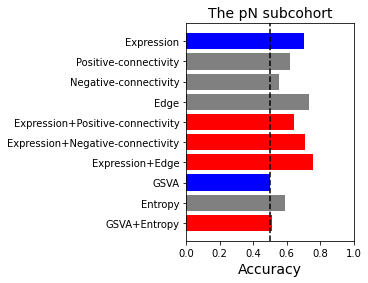

In [42]:
#colors =['#00BFC4' if i == 0 else 'gray' for i in range(len(models))]
colors = ["blue","grey","grey","grey","red","red","red","blue","grey","red"]

dfacc = pd.DataFrame.from_dict(dic_acc, orient='index')
dfacc.columns = ["ACC"]

plt.figure(figsize=(3, 4))
bars = plt.barh(dfauc.index, dfacc["ACC"],color=colors)

plt.axvline(0.5, color='black', linestyle='--')

plt.xlim(0, 1)  # Set x-axis limits as per the data
plt.gca().invert_yaxis()
# Add AUC title at the top
plt.xlabel('Accuracy', fontsize=14)
plt.title('The pN subcohort', fontsize=14)
plt.savefig(f"all_markers_loocv_accuracy_lr.svg",dpi=600,bbox_inches='tight')
plt.show()

In [54]:
pd.DataFrame.from_dict(dic_f1, orient='index')

,0
Expression,0.699889
Positive-connectivity,0.618444
Negative-connectivity,0.555116
Edge,0.732542
Expression+Positive-connectivity,0.644444
Expression+Negative-connectivity,0.710825
Expression+Edge,0.755556
GSVA,0.499815
Entropy,0.585659
GSVA+Entropy,0.510627


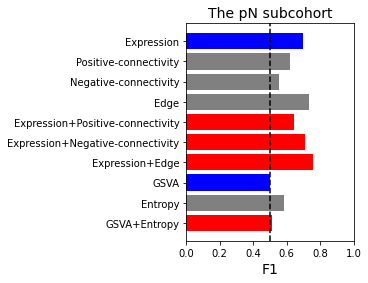

In [55]:
#colors =['#00BFC4' if i == 0 else 'gray' for i in range(len(models))]
colors = ["blue","grey","grey","grey","red","red","red","blue","grey","red"]

dff1 = pd.DataFrame.from_dict(dic_f1, orient='index')
dff1.columns = ["F1"]

plt.figure(figsize=(3, 4))
bars = plt.barh(dff1.index, dff1["F1"],color=colors)

plt.axvline(0.5, color='black', linestyle='--')

plt.xlim(0, 1)  # Set x-axis limits as per the data
plt.gca().invert_yaxis()
# Add AUC title at the top
plt.xlabel('F1', fontsize=14)
plt.title('The pN subcohort', fontsize=14)
plt.savefig(f"all_markers_loocv_F1_lr.svg",dpi=600,bbox_inches='tight')
plt.show()

In [56]:
# SVC

In [ ]:
from sklearn.svm import SVC
dic_acc ={}
dic_f1 = {}
for datetype,dataname,k_num in \
    zip([modelinput_expr,connec_pos_input,connec_neg_input,edges_input,\
         connec_pos_input_improved,connec_neg_input_improved,modelinput_expr.join(edges_input,lsuffix='expr', rsuffix='edges'),\
         gsva_input,entropy_input,entropy_input_improved],\
        ["Expression","Positive-connectivity","Negative-connectivity","Edge","Expression+Positive-connectivity",
         "Expression+Negative-connectivity","Expression+Edge","GSVA","Entropy","GSVA+Entropy"],\
       [10,80,20,60, 20,10,100, 10,10,40]):

    models = []
    models.append(('SVC',SVC(class_weight='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
            # Create a pipeline
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('feature_selection', SelectKBest(score_func=f_classif, k=k_num)), 
            ('logistic_regression', model)       # Logistic Regression model
    ])
    
        # Evaluate the pipeline with LOOCV
        result = cross_val_score(estimator=pipeline,
                                          X=datetype,
                                          y=dfcl["Benefit"],
                                          cv=loo,
                                          scoring="accuracy",n_jobs=-1 )
        names.append(name)
        dic_acc[dataname] = np.mean(result)

        # Define a custom scorer with the correct pos_label
        y_pred = cross_val_predict(pipeline, datetype, dfcl["Benefit"], cv=loo)
        # Compute F1 score on aggregated predictions
        f1 = f1_score(dfcl["Benefit"], y_pred, average='weighted') 
        
        dic_f1[dataname] = f1
        

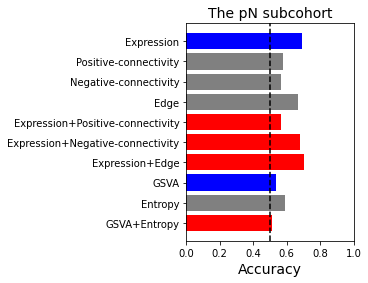

In [68]:
#colors =['#00BFC4' if i == 0 else 'gray' for i in range(len(models))]
colors = ["blue","grey","grey","grey","red","red","red","blue","grey","red"]

dfacc = pd.DataFrame.from_dict(dic_acc, orient='index')
dfacc.columns = ["ACC"]

plt.figure(figsize=(3, 4))
bars = plt.barh(dfauc.index, dfacc["ACC"],color=colors)

plt.axvline(0.5, color='black', linestyle='--')

plt.xlim(0, 1)  # Set x-axis limits as per the data
plt.gca().invert_yaxis()
# Add AUC title at the top
plt.xlabel('Accuracy', fontsize=14)
plt.title('The pN subcohort', fontsize=14)
plt.savefig(f"all_markers_loocv_accuracy_SVM.svg",dpi=600,bbox_inches='tight')
plt.show()

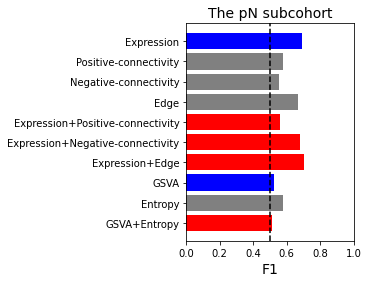

In [69]:
#colors =['#00BFC4' if i == 0 else 'gray' for i in range(len(models))]
colors = ["blue","grey","grey","grey","red","red","red","blue","grey","red"]

dff1 = pd.DataFrame.from_dict(dic_f1, orient='index')
dff1.columns = ["F1"]

plt.figure(figsize=(3, 4))
bars = plt.barh(dff1.index, dff1["F1"],color=colors)

plt.axvline(0.5, color='black', linestyle='--')

plt.xlim(0, 1)  # Set x-axis limits as per the data
plt.gca().invert_yaxis()
# Add AUC title at the top
plt.xlabel('F1', fontsize=14)
plt.title('The pN subcohort', fontsize=14)
plt.savefig(f"all_markers_loocv_F1_SVM.svg",dpi=600,bbox_inches='tight')
plt.show()

In [70]:
# RF

In [ ]:
from sklearn.ensemble import RandomForestClassifier
dic_acc ={}
dic_f1 = {}
for datetype,dataname,k_num in \
    zip([modelinput_expr,connec_pos_input,connec_neg_input,edges_input,\
         connec_pos_input_improved,connec_neg_input_improved,modelinput_expr.join(edges_input,lsuffix='expr', rsuffix='edges'),\
         gsva_input,entropy_input,entropy_input_improved],\
        ["Expression","Positive-connectivity","Negative-connectivity","Edge","Expression+Positive-connectivity",
         "Expression+Negative-connectivity","Expression+Edge","GSVA","Entropy","GSVA+Entropy"],\
       [10,30,20,60, 10,10,20, 10,40,40]):

    models = []
    models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
            # Create a pipeline
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('feature_selection', SelectKBest(score_func=f_classif, k=k_num)), 
            ('logistic_regression', model)       # Logistic Regression model
    ])
    
        # Evaluate the pipeline with LOOCV
        result = cross_val_score(estimator=pipeline,
                                          X=datetype,
                                          y=dfcl["Benefit"],
                                          cv=loo,
                                          scoring="accuracy",n_jobs=-1 )
        names.append(name)
        dic_acc[dataname] = np.mean(result)

        # Define a custom scorer with the correct pos_label
        y_pred = cross_val_predict(pipeline, datetype, dfcl["Benefit"], cv=loo)
        # Compute F1 score on aggregated predictions
        f1 = f1_score(dfcl["Benefit"], y_pred, average='weighted') 
        
        dic_f1[dataname] = f1
        

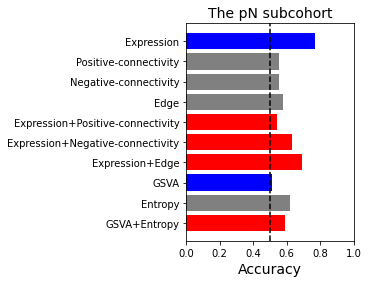

In [72]:
#colors =['#00BFC4' if i == 0 else 'gray' for i in range(len(models))]
colors = ["blue","grey","grey","grey","red","red","red","blue","grey","red"]

dfacc = pd.DataFrame.from_dict(dic_acc, orient='index')
dfacc.columns = ["ACC"]

plt.figure(figsize=(3, 4))
bars = plt.barh(dfauc.index, dfacc["ACC"],color=colors)

plt.axvline(0.5, color='black', linestyle='--')

plt.xlim(0, 1)  # Set x-axis limits as per the data
plt.gca().invert_yaxis()
# Add AUC title at the top
plt.xlabel('Accuracy', fontsize=14)
plt.title('The pN subcohort', fontsize=14)
plt.savefig(f"all_markers_loocv_accuracy_RF.svg",dpi=600,bbox_inches='tight')
plt.show()

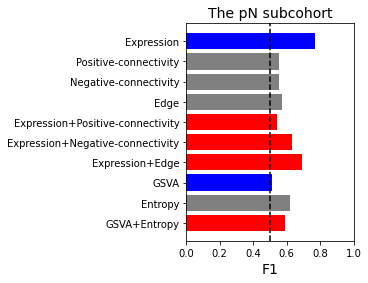

In [73]:
#colors =['#00BFC4' if i == 0 else 'gray' for i in range(len(models))]
colors = ["blue","grey","grey","grey","red","red","red","blue","grey","red"]

dff1 = pd.DataFrame.from_dict(dic_f1, orient='index')
dff1.columns = ["F1"]

plt.figure(figsize=(3, 4))
bars = plt.barh(dff1.index, dff1["F1"],color=colors)

plt.axvline(0.5, color='black', linestyle='--')

plt.xlim(0, 1)  # Set x-axis limits as per the data
plt.gca().invert_yaxis()
# Add AUC title at the top
plt.xlabel('F1', fontsize=14)
plt.title('The pN subcohort', fontsize=14)
plt.savefig(f"all_markers_loocv_F1_RF.svg",dpi=600,bbox_inches='tight')
plt.show()

In [74]:
# DNN

In [ ]:
from sklearn.neural_network import MLPClassifier
dic_acc ={}
dic_f1 = {}
for datetype,dataname,k_num in \
    zip([modelinput_expr,connec_pos_input,connec_neg_input,edges_input,\
         connec_pos_input_improved,connec_neg_input_improved,modelinput_expr.join(edges_input,lsuffix='expr', rsuffix='edges'),\
         gsva_input,entropy_input,entropy_input_improved],\
        ["Expression","Positive-connectivity","Negative-connectivity","Edge","Expression+Positive-connectivity",
         "Expression+Negative-connectivity","Expression+Edge","GSVA","Entropy","GSVA+Entropy"],\
       [10,50,20,50, 70,10,90, 10,30,50]):

    models = []
    models.append(('DNN',MLPClassifier(activation='relu',solver='adam',random_state=42,max_iter=2000,)))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
            # Create a pipeline
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('feature_selection', SelectKBest(score_func=f_classif, k=k_num)), 
            ('logistic_regression', model)       # Logistic Regression model
    ])
    
        # Evaluate the pipeline with LOOCV
        result = cross_val_score(estimator=pipeline,
                                          X=datetype,
                                          y=dfcl["Benefit"],
                                          cv=loo,
                                          scoring="accuracy",n_jobs=-1 )
        names.append(name)
        dic_acc[dataname] = np.mean(result)

        # Define a custom scorer with the correct pos_label
        y_pred = cross_val_predict(pipeline, datetype, dfcl["Benefit"], cv=loo)
        # Compute F1 score on aggregated predictions
        f1 = f1_score(dfcl["Benefit"], y_pred, average='weighted') 
        
        dic_f1[dataname] = f1
        

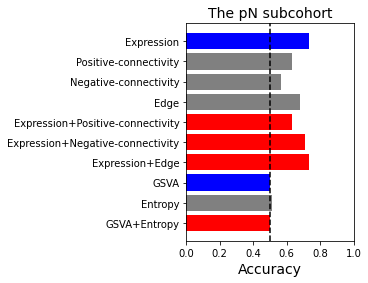

In [76]:
#colors =['#00BFC4' if i == 0 else 'gray' for i in range(len(models))]
colors = ["blue","grey","grey","grey","red","red","red","blue","grey","red"]

dfacc = pd.DataFrame.from_dict(dic_acc, orient='index')
dfacc.columns = ["ACC"]

plt.figure(figsize=(3, 4))
bars = plt.barh(dfauc.index, dfacc["ACC"],color=colors)

plt.axvline(0.5, color='black', linestyle='--')

plt.xlim(0, 1)  # Set x-axis limits as per the data
plt.gca().invert_yaxis()
# Add AUC title at the top
plt.xlabel('Accuracy', fontsize=14)
plt.title('The pN subcohort', fontsize=14)
plt.savefig(f"all_markers_loocv_accuracy_DNN.svg",dpi=600,bbox_inches='tight')
plt.show()

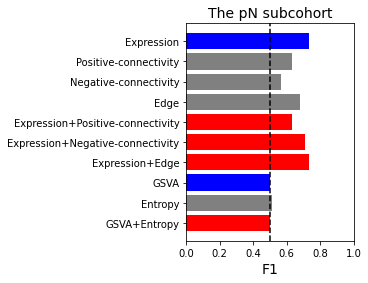

In [77]:
#colors =['#00BFC4' if i == 0 else 'gray' for i in range(len(models))]
colors = ["blue","grey","grey","grey","red","red","red","blue","grey","red"]

dff1 = pd.DataFrame.from_dict(dic_f1, orient='index')
dff1.columns = ["F1"]

plt.figure(figsize=(3, 4))
bars = plt.barh(dff1.index, dff1["F1"],color=colors)

plt.axvline(0.5, color='black', linestyle='--')

plt.xlim(0, 1)  # Set x-axis limits as per the data
plt.gca().invert_yaxis()
# Add AUC title at the top
plt.xlabel('F1', fontsize=14)
plt.title('The pN subcohort', fontsize=14)
plt.savefig(f"all_markers_loocv_F1_DNN.svg",dpi=600,bbox_inches='tight')
plt.show()